In [ ]:
## Hypotheses

Before visualising the learned embedding space, I want to record my 
expectations based on my reading of Bengio et al. (2003) and my 
understanding of how the model trains.

The central idea: characters that appear in similar contexts (followed 
by similar distributions of next characters) should end up close 
together in embedding space. The network learns to give them similar 
representations because similar representations lead to similar 
predictions, which is what the training signal rewards.

 1. Vowels will cluster
`a, e, i, o, u` occupy similar roles in names, they appear between 
consonants, at name endings, and are followed by similar distributions 
of next characters. I expect them to form the tightest and most obvious 
cluster in the plot.

 2. Certain consonants will cluster
Through simple observation I noticed that m, n, l feel interchangeable 
in names (mara/nara/lara, leon/neon) where replacing one for another 
often produces another plausible name. A quick search told me this is 
because they belong to a class called sonorants, consonants produced 
with continuous airflow that behave similarly to vowels in terms of 
where they appear in words. I'll extend this to m, n, l, r and 
tentatively s and w, though generalising too far feels premature and 
id rather let the plot tell me.

 3. Rare characters will be outliers
q, x, z appear very infrequently in English names so the model has seen 
very little of what follows them. I expect them to sit in arbitrary 
regions of the space, far from the main clusters.

 4. The '.' token will be isolated 
The special start/end token only ever appears at the boundaries of 
names, never in the middle, and nothing else in the vocabulary behaves 
like it. I expect it to be a clear outlier.

In [54]:
import torch
import torch.nn.functional as f
words=open('names.txt','r').read().splitlines()

In [55]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}

import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
words_train=words[:n1]
words_dev=words[n1:n2]
words_test=words[n2:]


In [373]:
def build_dataset(words):
    block_size=3
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            x1=stoi[ch]
            X.append(context)
            Y.append(x1)
        context=context[1:]+[x1]
    return X,Y
x_train_raw, y_train = build_dataset(words_train)
x_dev_raw,   y_dev   = build_dataset(words_dev)
x_test_raw,  y_test  = build_dataset(words_test)
x_train = torch.tensor(x_train_raw)
x_dev   = torch.tensor(x_dev_raw)
x_test  = torch.tensor(x_test_raw)
y_train = torch.tensor(y_train)
y_dev   = torch.tensor(y_dev)
y_test  = torch.tensor(y_test)



In [374]:

g=torch.Generator().manual_seed(2147483647+1)
W1=torch.randn((6,100),generator=g,requires_grad=True)
b1=torch.zeros(100,requires_grad=True)
W2 = torch.randn((100, 27), generator=g) * 0.01
W2.requires_grad = True
b2=torch.zeros(27,requires_grad=True)
C=torch.randn((27,2),generator=g,requires_grad=True)
loss=0
params=[C,W1,b1,W2,b2]

In [410]:
for i in range(20000):
    ix=torch.randint(0,x_train.shape[0],(32,))
    emb=C[x_train[ix]]
    h=torch.tanh(emb.view(emb.shape[0],6)@ W1 + b1) #coolerimo
    logits=h @W2 + b2
    loss=f.cross_entropy(logits,y_train[ix])

  
    for p in params:
        p.grad=None
    loss.backward()
    #updare
   # lr=lrs[i]
    for p in params:
        p.data+=-0.06 * p.grad
print(loss.item())

2.3619351387023926


In [411]:
with torch.no_grad():
    emb = C[x_dev]
    h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss_dev = f.cross_entropy(logits, y_dev)
    print(f"dev loss: {loss_dev.item():.4f}")

dev loss: 2.8250


In [412]:

#smoothed = torch.tensor(lossi).unfold(0, 100, 1).mean(1)
#plt.plot(smoothed)
#plt.show()

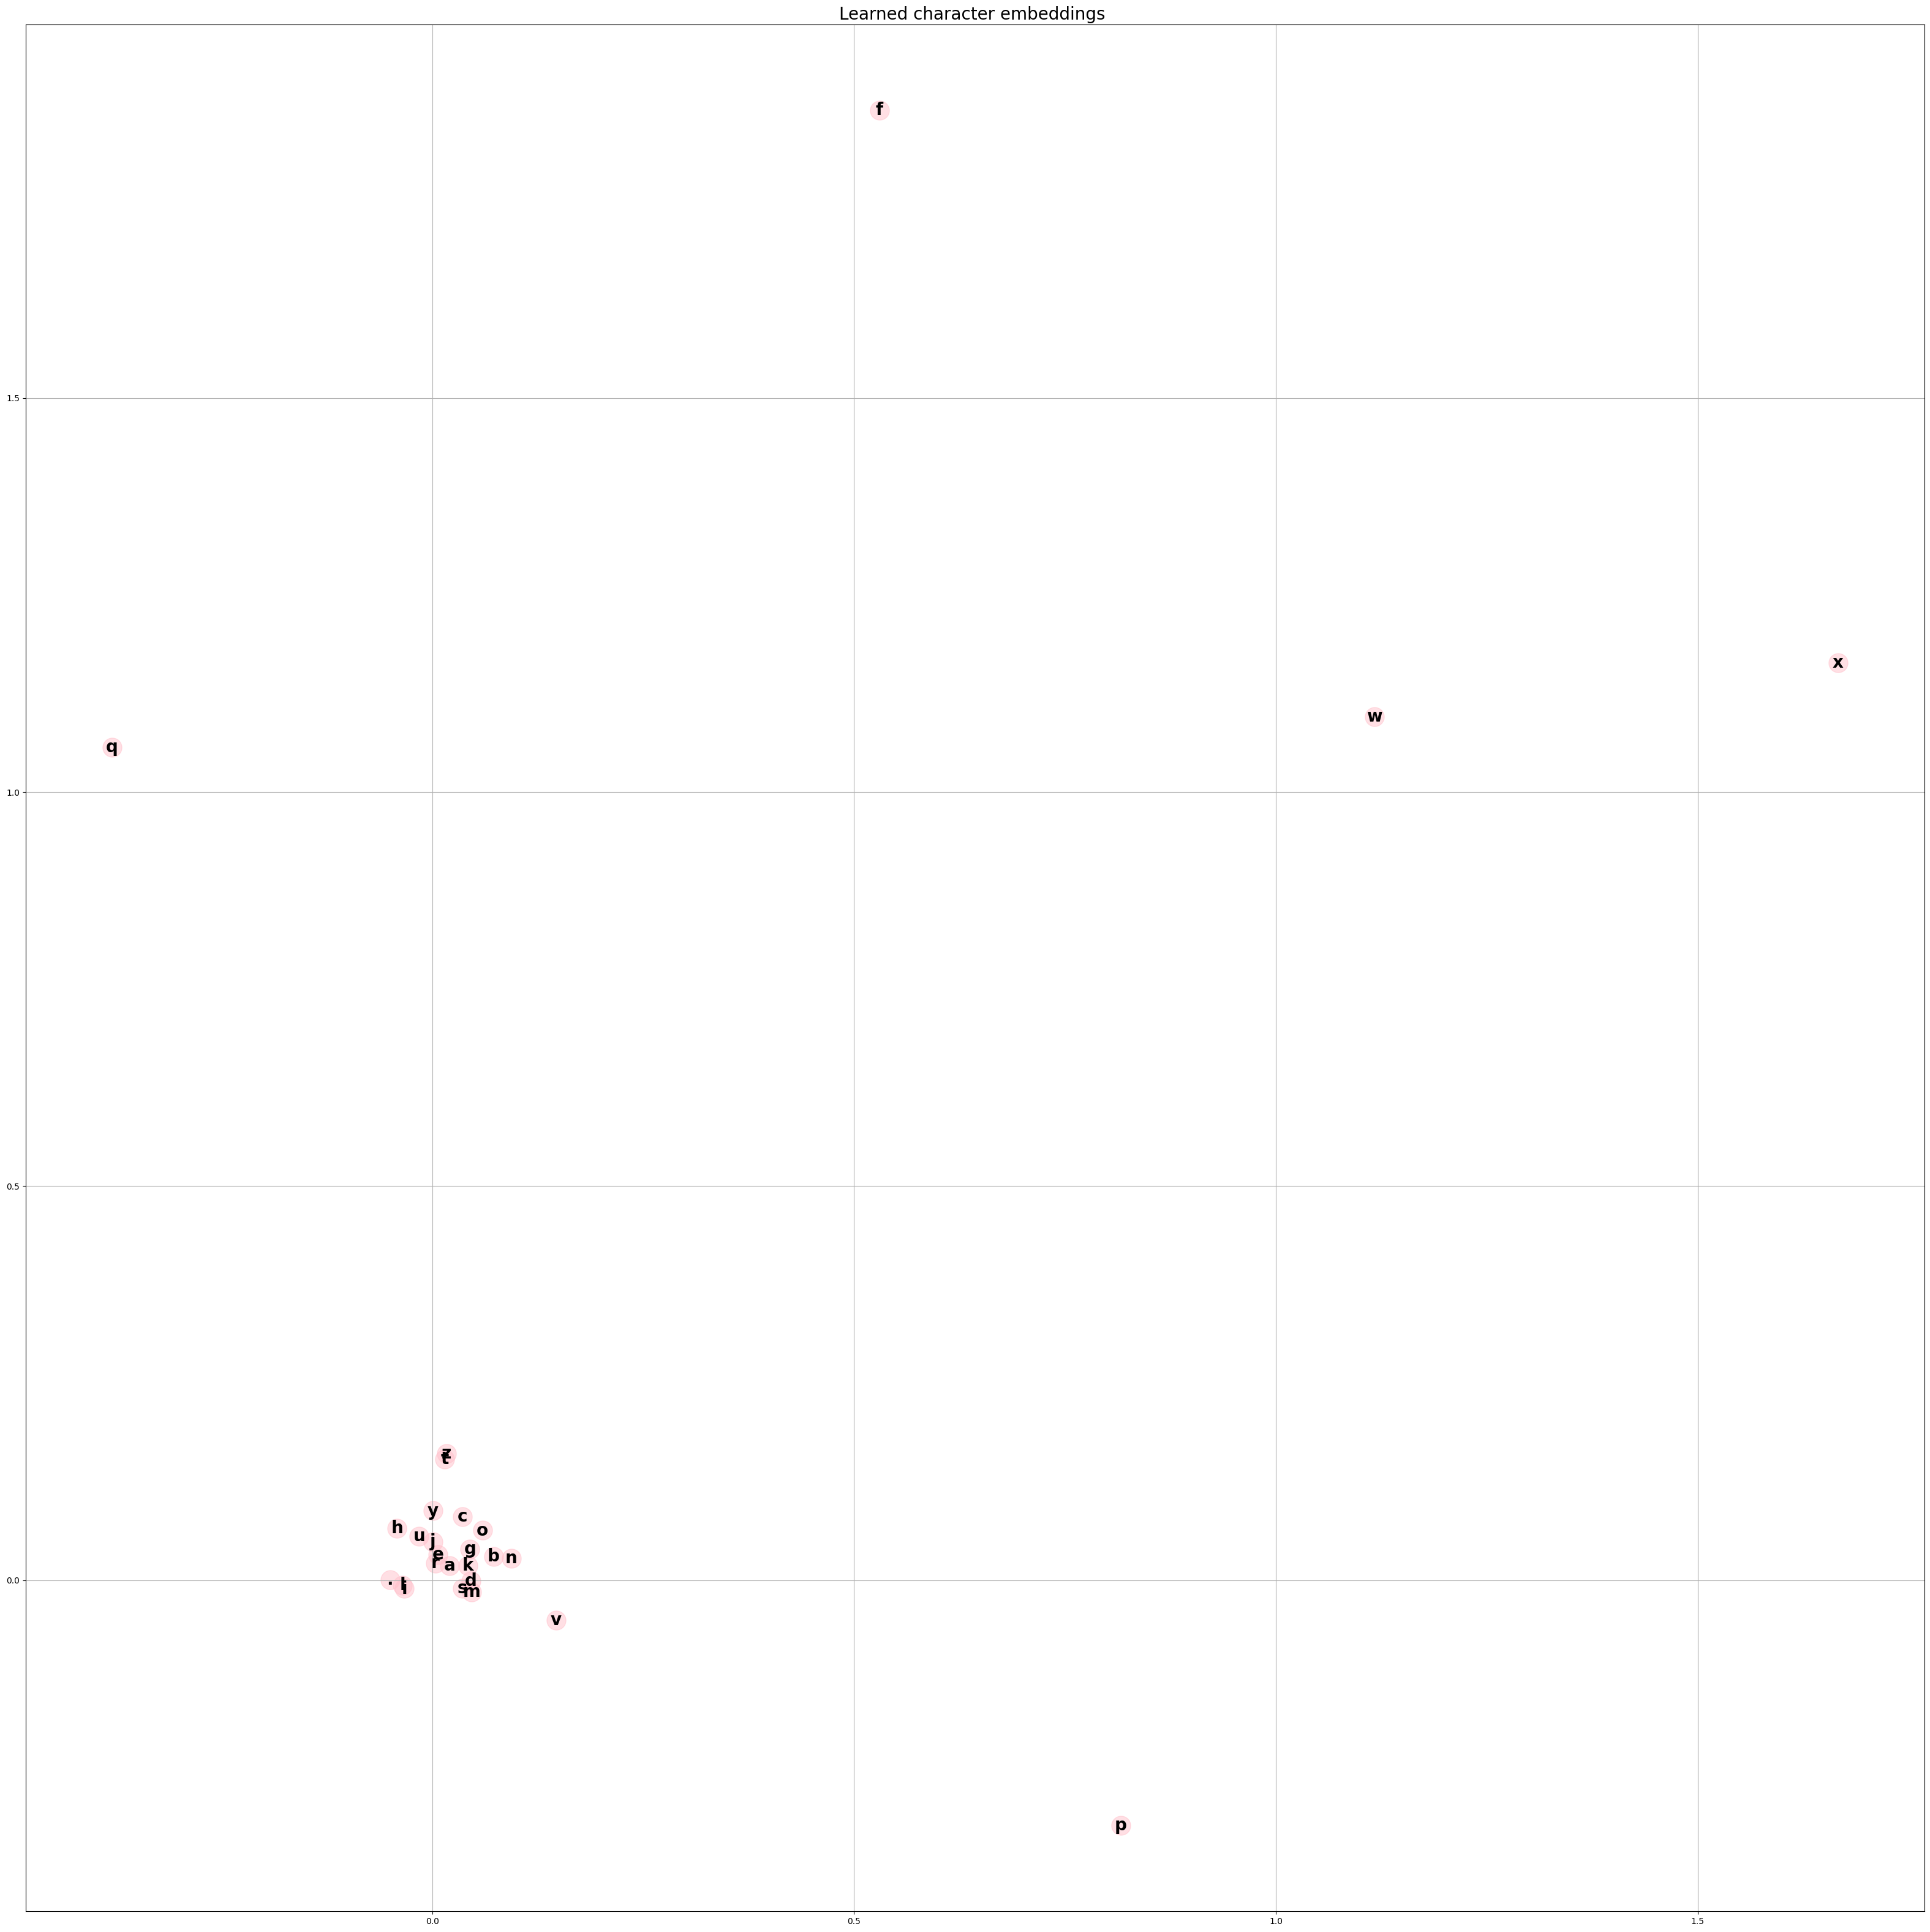

In [444]:
C_plot = C.detach().numpy()
x = C_plot[:, 0]
y = C_plot[:, 1]

plt.figure(figsize=(40, 40))
plt.scatter(x, y, s=500, alpha=0.5,c='pink')
for i, ch in itos.items():
    plt.text(x[i], y[i], ch, ha='center', va='center', fontsize=20, fontweight='bold')
plt.grid(True)
plt.title('Learned character embeddings ', fontsize=20)
plt.show()

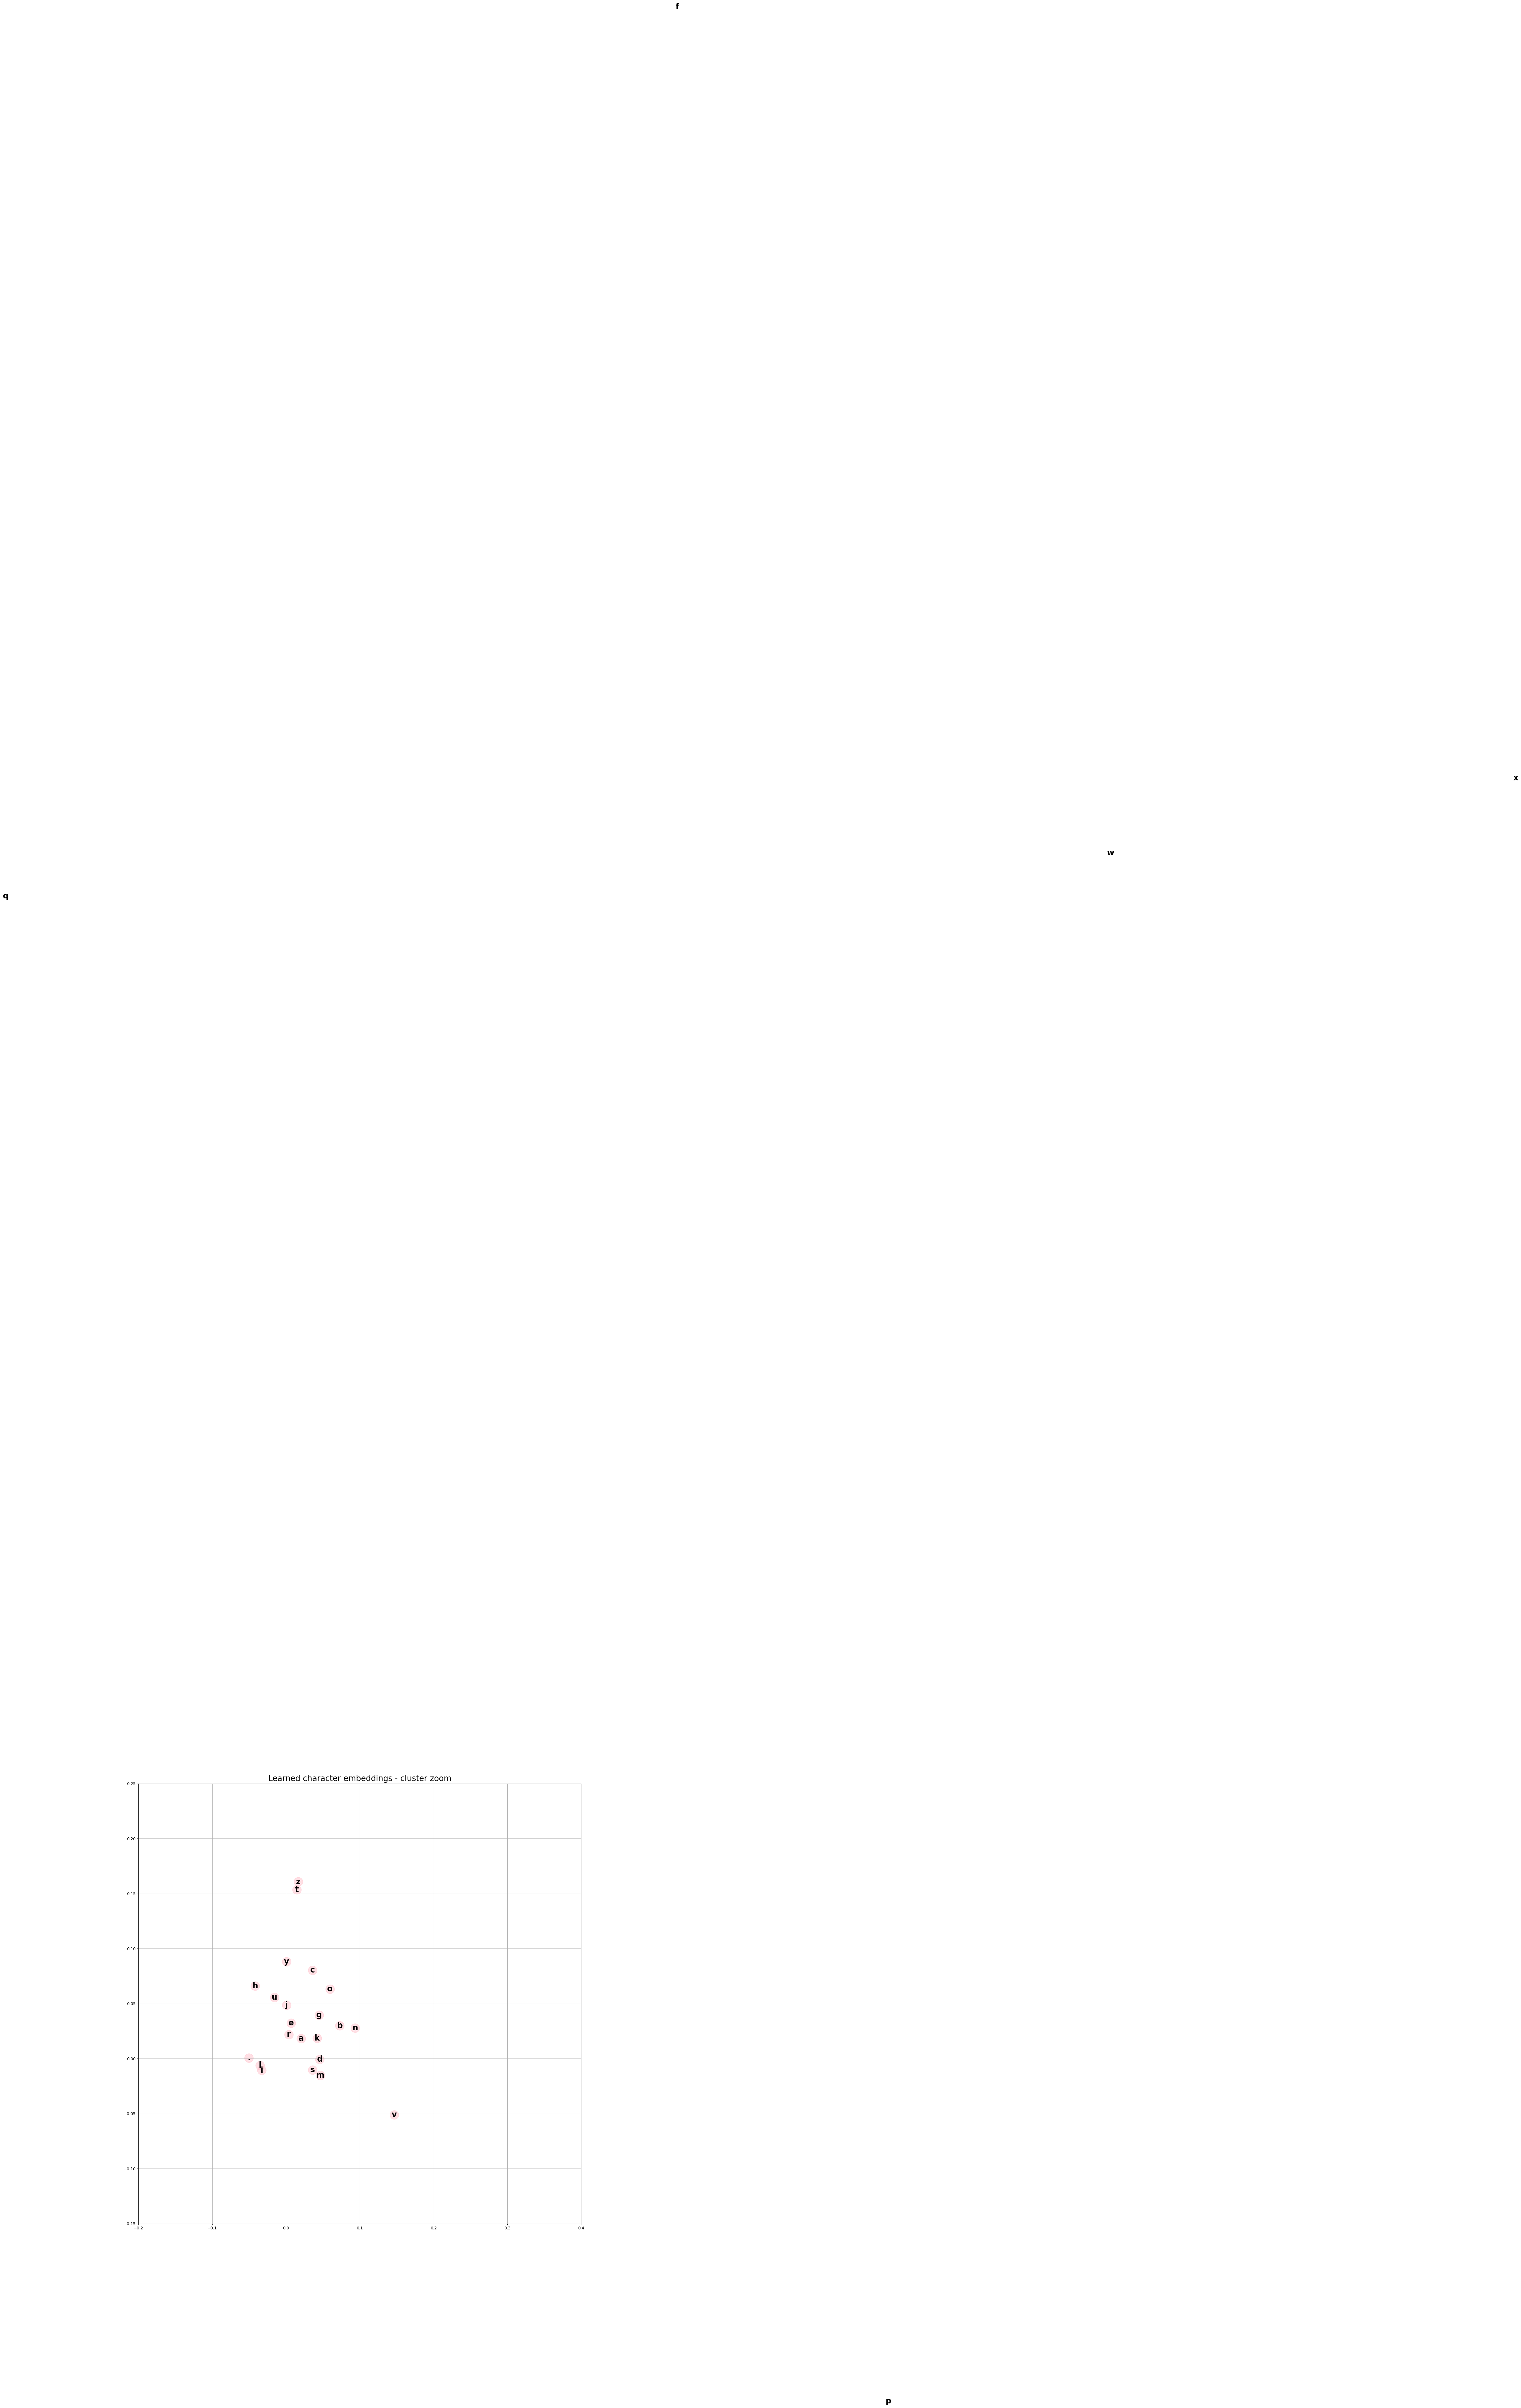

In [445]:
C_plot = C.detach().numpy()
x = C_plot[:, 0]
y = C_plot[:, 1]

plt.figure(figsize=(20, 20))
plt.scatter(x, y, s=500, alpha=0.5,c='pink')
for i, ch in itos.items():
    plt.text(x[i], y[i], ch, ha='center', va='center', fontsize=20, fontweight='bold')
plt.grid(True)
plt.title('Learned character embeddings - cluster zoom', fontsize=20)
plt.xlim(-0.2, 0.4)
plt.ylim(-0.15, 0.25)
plt.show()

In [452]:
def top_followers(words, n=5):
    all_chars = sorted(stoi.keys())
    for ch in all_chars:
        freq = {}
        for w in words:
            chs = ['.'] + list(w) + ['.']
            for i in range(len(chs)-1):
                if chs[i] == ch:
                    next_ch = chs[i+1]
                    freq[next_ch] = freq.get(next_ch, 0) + 1
        top = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n]
        print(f"'{ch}' -> {top}")

top_followers(words_train)

'.' -> [('a', 3545), ('k', 2395), ('m', 2001), ('j', 1921), ('s', 1650)]
'a' -> [('.', 5273), ('n', 4389), ('r', 2618), ('l', 2011), ('h', 1894)]
'b' -> [('r', 681), ('e', 518), ('a', 252), ('i', 162), ('.', 87)]
'c' -> [('a', 628), ('h', 531), ('e', 439), ('o', 302), ('k', 247)]
'd' -> [('a', 1044), ('e', 1032), ('i', 534), ('.', 430), ('r', 343)]
'e' -> [('.', 3176), ('l', 2616), ('n', 2115), ('r', 1563), ('e', 1019)]
'f' -> [('a', 200), ('i', 124), ('e', 94), ('r', 91), ('.', 65)]
'g' -> [('h', 284), ('a', 270), ('e', 267), ('r', 158), ('i', 158)]
'h' -> [('.', 1945), ('a', 1795), ('i', 587), ('e', 542), ('o', 226)]
'i' -> [('.', 1984), ('a', 1968), ('n', 1683), ('e', 1316), ('l', 1069)]
'j' -> [('a', 1180), ('o', 373), ('e', 343), ('u', 168), ('i', 92)]
'k' -> [('a', 1394), ('e', 715), ('i', 407), ('y', 310), ('.', 286)]
'l' -> [('e', 2343), ('a', 2118), ('i', 1987), ('y', 1266), ('l', 1092)]
'm' -> [('a', 2048), ('i', 1001), ('e', 656), ('.', 410), ('o', 361)]
'n' -> [('.', 5404),

In [ ]:
## Analysis

### Outliers are the clearest signal

- q, x, f, p, and w sit far from the main cluster.
- The naive explanation would be that these are simply rare characters, but the more precise finding is that they are rare specifically in names, not in English generally.
- p and f are common English characters but infrequent in names, and the model treats them accordingly.
- This directly validates Bengio's core claim that the learned embedding reflects task-specific frequency rather than general corpus statistics.
- A pre-computed co-occurrence embedding would likely have placed p and f much closer to the centre.

### Outlier structure is driven by unique following distributions

- q is almost exclusively followed by u, the strongest single-successor pattern in the dataset.
- p is strongly followed by h through the "ph".
- x appears more often as a name-ending character than as a predecessor to other characters.
- Each outlier therefore develops a highly specialised following distribution, pushing it away from the rest of the embedding space.

### Vowels partially cluster, but not uniformly

- a and e form the closest vowel pair.
  - Both frequently end names.
  - Both are followed by similar consonants such as n, r, and l.
- o sits furthest from the vowel group because it more commonly precedes n and r rather than acting as a terminal vowel.
- i becomes relatively isolated due to the "ia" pattern.
  - It is the only vowel whose second most common follower is another vowel.
  - This reflects endings such as julia, olivia, and sofia.

### Following distribution matters more than phonetics

- y and h appear close together despite having no strong phonetic similarity.
- Their top two followers are both "." and "a".
- The model has no notion of phonetics; it only learns next-character statistics.
- This was one of the most counterintuitive results because it demonstrates how purely task-driven the embedding becomes.

### s and g drift toward the vowel region

- Both frequently precede h through digraphs such as:
  - sh
  - gh
- After these digraphs, vowels often follow.
- The model therefore learns an indirect association between these consonants and vowel-heavy continuations.

### "." is not isolated as hypothesised

- The "." token sits within the main cluster near l and i rather than separating cleanly.
- This likely occurs because it plays two competing roles:
  - preceding the first character of a name
  - following the final character of a name
- Gradients from these opposing contexts pull the embedding in multiple directions, causing it to settle into a relatively neutral position.

### Limitation

- At a dev loss of 2.36 with only two embedding dimensions, the space is heavily compressed.
- The broad outliers and large-scale groupings appear meaningful.
- However, fine-grained distances inside the dense central cluster may simply reflect limited model capacity rather than genuinely interpretable structure.